# LAB10 — Variacioni i Performancës së Kompjuterit

**Studenti:** Klaus Dragjoshi  

**Lënda:** Hyrje Laborator (Fizike dhe Shkenca Kompjuterike)

**Data:** 15.05.2026

## 1. Qëllimi i Eksperimentit
Qëllimi i këtij laboratori është studimi i variacionit të kohës së ekzekutimit të një algoritmi duke përsëritur matjet në mënyrë të njëpasnjëshme. Synohet të analizohen burimet fizike dhe sistemore që e bëjnë performancën jo-deterministe.

## 2. Metodologjia dhe Kodi Kryesor
Për këtë eksperiment, kemi zgjedhur një algoritëm të thjeshtë (shuma e një liste) me një input të fiksuar $n = 10^5$. Matja kryhet duke përdorur funksionin time.perf_counter() për të siguruar saktësi të lartë, duke përsëritur matjen 1000 herë për të gjeneruar një shpërndarje statistikore.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

def shuma_algoritmi(n):
    # Një cikël i thjeshtë për të matur kohën
    total = 0
    for i in range(n):
        total += i
    return total

def measure_execution(n, repetitions=1000):
    times = []
    for _ in range(repetitions):
        start = time.perf_counter()
        shuma_algoritmi(n)
        end = time.perf_counter()
        times.append(end - start)
    return np.array(times)

# Fiksojmë input-in n
n_input = 100000
kohët = measure_execution(n_input)

print(f"U kryen {len(kohët)} matje për n = {n_input}")

U kryen 1000 matje për n = 100000


## 3. Analiza Statistikore
Në këtë seksion llogarisim parametrat kryesorë statistikore:
- Mesataren ($\bar{T}$)
- Devijimin Standard ($\sigma$)
- Vlerat Minimale dhe Maksimale
- Koeficientin e Variacionit ($CV = \frac{\sigma}{\bar{T}} \times 100$)

## 4. Vizualizimi i Shpërndarjes (Histogrami)
Për të parë formën e shpërndarjes së kohëve, ndërtojmë një histogram. Kjo na ndihmon të vërejmë nëse shpërndarja është "Normale" dhe nëse ka "outliers" .

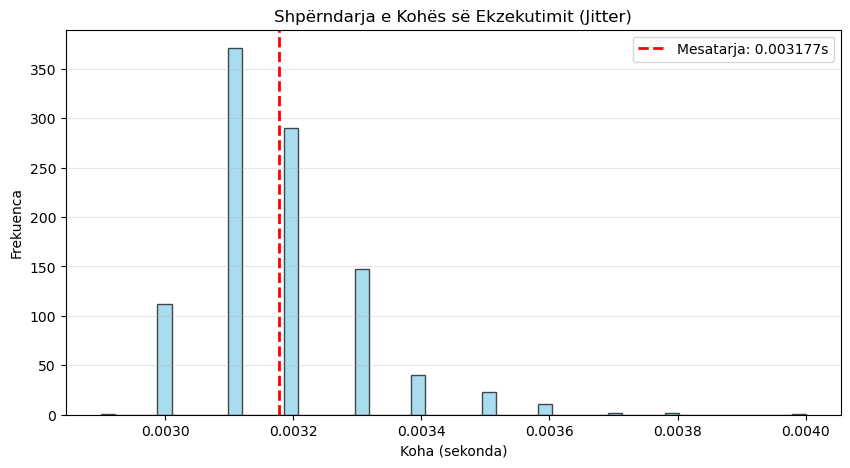

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Llogarisim mesataren brenda qelizës që të mos kemi NameError
t_mean = np.mean(kohët)

# 2. Ndërtimi i grafikut
plt.figure(figsize=(10, 5))
plt.hist(kohët, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# 3. Shtimi i vijës së mesatares (tani t_mean është e njohur)
plt.axvline(t_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mesatarja: {t_mean:.6f}s')

plt.title('Shpërndarja e Kohës së Ekzekutimit (Jitter)')
plt.xlabel('Koha (sekonda)')
plt.ylabel('Frekuenca')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 5. Diskutimi i Rezultateve
Nga të dhënat e mbledhura vërejmë se koha e ekzekutimit nuk është një vlerë fikse konstante. 
- **Variacioni ($\sigma$):** Tregon luhatjen e shkaktuar nga zhurma e sistemit (OS scheduling, interrupts).
- **Outliers:** Vlerat maksimale ($T_{max}$) shpesh vijnë si pasojë e ndërprerjeve nga proceset në sfond.
- **Forma:** Shpërndarja tenton drejt formës normale, duke treguar se procesi është analog me matjet fizike në laborator.

## 6. Përfundimi
Ky laborator demonstroi se performanca e kompjuterit nuk është deterministe në praktikë. Ajo duhet trajtuar si një fenomen statistik. Përsëritja e matjeve është e domosdoshme për të marrë një rezultat të besueshëm mbi shpejtësinë reale të një algoritmi.